# Response-identification scorecard - runs E to H

This notebook drives the A0.4 scorecard (scripts_joint/response_scorecard.py) over every
joint run from Run_E through the Run_H family and turns the result into one table.

Two axes are scored per checkpoint:

- **Axis R - response identification**: for a fixed truth event, decode many times and compare
  the within-z width with the resolution the detector needs. A deterministic map that fakes the
  resolution with its mean map shows within/required far below 1 and is flagged degenerate.
- **Axis C - conditional closure**: per pair-pT slice mass W1 divided by its finite-sample floor.

Axis T (Upsilon transfer) is report-only and can never enter the selection key; that is enforced
by a unit test in tests/test_response_scorecard.py.

Set REFRESH = True in the next cell to rebuild any missing scorecard; the notebook itself only
reads outputs/cms_Joint/scorecard/<run>/scorecard.json.


In [1]:
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().resolve()
while not (REPO / "scripts_joint" / "response_scorecard.py").exists() and REPO != REPO.parent:
    REPO = REPO.parent

SCORECARD = REPO / "outputs" / "cms_Joint" / "scorecard"
RUNS = [
    "Run_E", "Run_F", "Run_G_tf32", "Run_H", "Run_H_fix", "Run_H_anchor",
    "Run_H_cycleNoNoise", "Run_H_A2frozen", "Run_H_A2floor",
    "Run_H_A2cycleNoise", "Run_H_A2cycW5native",
    "Run_H_A2frozen_all",   # every retained A2frozen checkpoint (g20 warmup included)
]
REFRESH = False        # True = rebuild scorecards that are missing
DEVICE = "cuda"
SLICE_SAMPLES = 40000


def render(value, digits=3):
    if value is None:
        return "n/a"
    if isinstance(value, bool):
        return "yes" if value else "no"
    if isinstance(value, float):
        return "n/a" if math.isnan(value) else format(value, "." + str(digits) + "g")
    return str(value)


def show_table(rows, columns, digits=3):
    cells = [[render(row.get(column), digits) for column in columns] for row in rows]
    widths = [
        max([len(column)] + [len(row[index]) for row in cells])
        for index, column in enumerate(columns)
    ]
    print(" | ".join(column.ljust(width) for column, width in zip(columns, widths)))
    print("-+-".join("-" * width for width in widths))
    for row in cells:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


print("repo:", REPO)
print("scorecard root:", SCORECARD)


repo: C:\Users\AhrixMarin\Desktop\otus
scorecard root: C:\Users\AhrixMarin\Desktop\otus\outputs\cms_Joint\scorecard


In [2]:
missing = [name for name in RUNS if not (SCORECARD / name / "scorecard.json").exists()]
if REFRESH and missing:
    for name in missing:
        cmd = [
            sys.executable, str(REPO / "scripts_joint" / "response_scorecard.py"),
            "--run-dir", str(REPO / "outputs" / "cms_Joint" / name),
            "--device", DEVICE, "--slice-samples", str(SLICE_SAMPLES),
        ]
        print("running:", " ".join(cmd), flush=True)
        subprocess.run(cmd, check=True)
else:
    print("scorecards still missing:", missing or "none")


scorecards still missing: none


In [3]:
frame = []
payloads = {}
for name in RUNS:
    path = SCORECARD / name / "scorecard.json"
    if not path.exists():
        continue
    payload = json.loads(path.read_text(encoding="utf-8"))
    payloads[name] = payload
    for label, entry in payload["checkpoints"].items():
        gates = entry["gates"]
        response, conditional = gates["R"], gates["C"]
        row = {
            "run": name,
            "checkpoint": label,
            "epoch": entry.get("global_epoch"),
            "stage": (entry.get("stage_name") or "").replace("runH_", "").replace("runA_", ""),
            "R_pass": gates["R_pass"],
            "C_pass": gates["C_pass"],
            "degenerate": gates["degenerate"],
            "identified": gates["identified"],
            "in_domain": entry.get("in_domain_score"),
            "selection": payload["selection"]["status"],
            "selected": payload["selection"]["selected"],
            "slice_status": payload.get("slice_status"),
        }
        for region in ("jpsi", "z"):
            rblock = response.get(region) or {}
            cblock = conditional.get(region) or {}
            row[region + "_ratio"] = rblock.get("within_std_over_required")
            sigma = rblock.get("sigma_noise_only_gev")
            row[region + "_sigma_mev"] = None if sigma is None else 1000.0 * sigma
            row[region + "_share"] = rblock.get("noise_variance_fraction")
            row[region + "_slice"] = cblock.get("decode_ratio_median_native")
        frame.append(row)

print(len(frame), "checkpoints from", len(payloads), "runs")
show_table(frame, ["run", "checkpoint", "epoch", "stage", "R_pass", "C_pass",
                   "degenerate", "identified"])


30 checkpoints from 12 runs
run                 | checkpoint                                    | epoch | stage                            | R_pass | C_pass | degenerate | identified
--------------------+-----------------------------------------------+-------+----------------------------------+--------+--------+------------+-----------
Run_E               | best_model                                    | 65    | stage1_deterministic_identity    | no     | no     | yes        | no        
Run_E               | last_model                                    | 432   | stage4_tail_polish               | no     | no     | yes        | no        
Run_F               | best_model                                    | 20    | runF_stage1_deterministic_warmup | no     | no     | yes        | no        
Run_F               | last_model                                    | 100   | runF_stage2_stochastic_constant  | no     | no     | yes        | no        
Run_G_tf32          | best_model          

## Per-run selection key

The key rejects every checkpoint whose response gate fails or that is flagged degenerate, then
ranks the survivors by conditional closure and finally by the in-domain score. If nothing
survives it reports identification_failed instead of crowning a marginal winner.

In-domain scores are not comparable across the legacy-prior arms (Run_E to Run_H_anchor) and the
honest-prior A2 arms; the key is applied within a run, never across priors.


In [4]:
summary = []
for name in RUNS:
    block = [row for row in frame if row["run"] == name]
    if not block:
        continue
    summary.append({
        "run": name,
        "checkpoints": len(block),
        "selection": block[0]["selection"],
        "selected": block[0]["selected"],
        "identified": sum(1 for row in block if row["identified"]),
        "degenerate": sum(1 for row in block if row["degenerate"]),
        "axis_c": block[0]["slice_status"],
    })
show_table(summary, ["run", "checkpoints", "selection", "selected", "identified",
                     "degenerate", "axis_c"])


run                 | checkpoints | selection             | selected                                 | identified | degenerate | axis_c  
--------------------+-------------+-----------------------+------------------------------------------+------------+------------+---------
Run_E               | 2           | identification_failed | last_model                               | 0          | 2          | measured
Run_F               | 2           | identification_failed | last_model                               | 0          | 2          | measured
Run_G_tf32          | 2           | identification_failed | best_model                               | 0          | 2          | measured
Run_H               | 2           | identification_failed | last_model                               | 0          | 2          | measured
Run_H_fix           | 2           | identification_failed | last_model                               | 0          | 2          | measured
Run_H_anchor        | 2           

## Per-checkpoint gates

In [5]:
columns = ["run", "checkpoint", "epoch", "stage",
           "jpsi_ratio", "z_ratio", "jpsi_sigma_mev", "z_sigma_mev",
           "jpsi_slice", "z_slice", "R_pass", "C_pass", "degenerate", "in_domain"]
show_table(frame, columns)


run                 | checkpoint                                    | epoch | stage                            | jpsi_ratio | z_ratio | jpsi_sigma_mev | z_sigma_mev | jpsi_slice | z_slice | R_pass | C_pass | degenerate | in_domain
--------------------+-----------------------------------------------+-------+----------------------------------+------------+---------+----------------+-------------+------------+---------+--------+--------+------------+----------
Run_E               | best_model                                    | 65    | stage1_deterministic_identity    | 0          | 0       | 0              | 0           | 3.32       | 2.2     | no     | no     | yes        | 0.612    
Run_E               | last_model                                    | 432   | stage4_tail_polish               | 1.68       | 0.0875  | 24.9           | 256         | 7.18       | 1.9     | no     | no     | yes        | 1.24     
Run_F               | best_model                                    | 20    

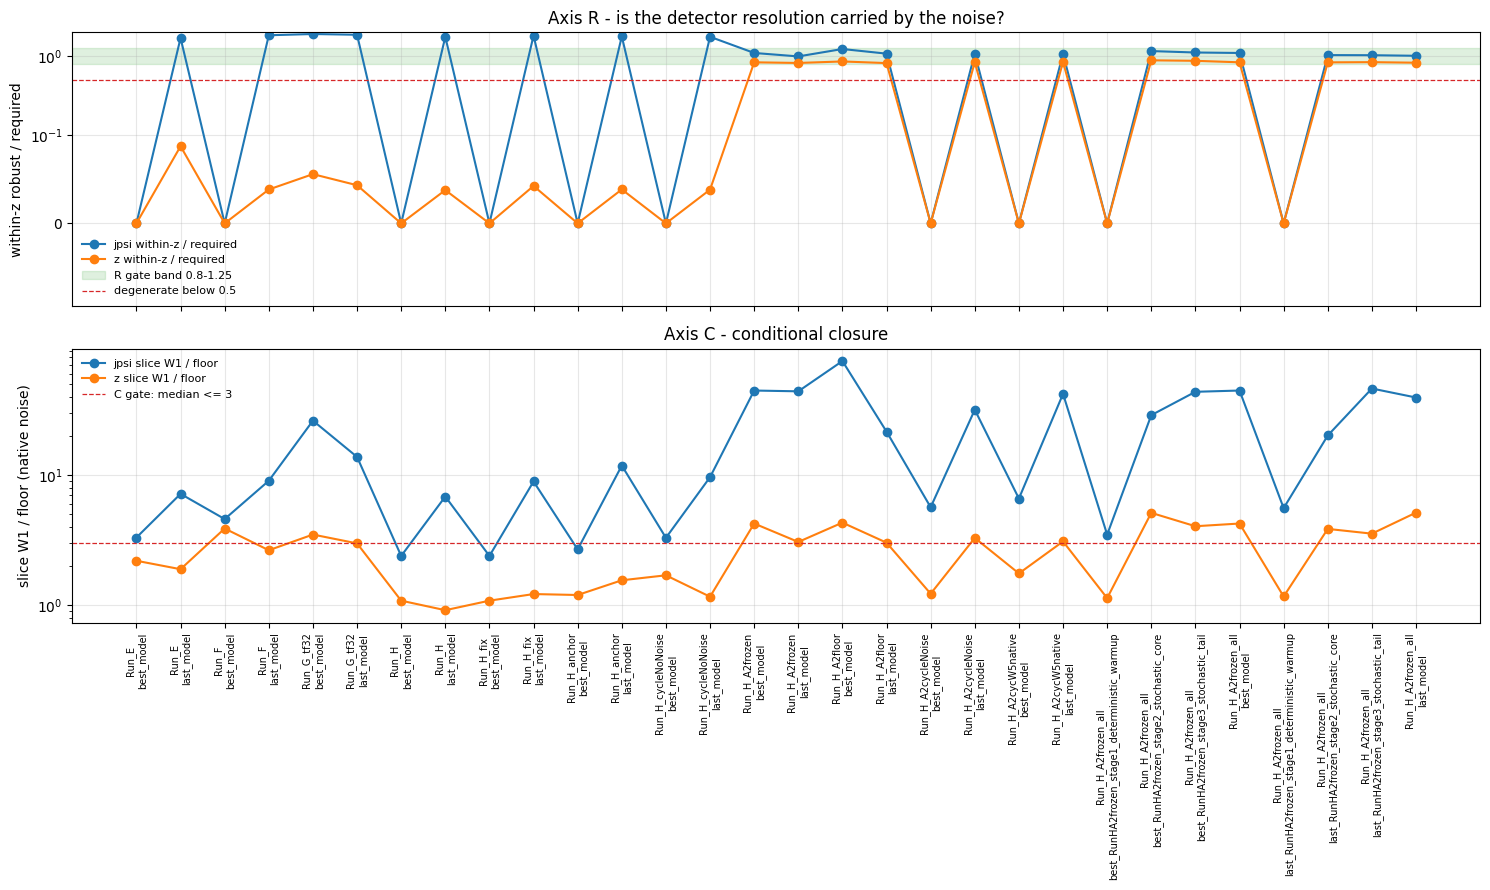

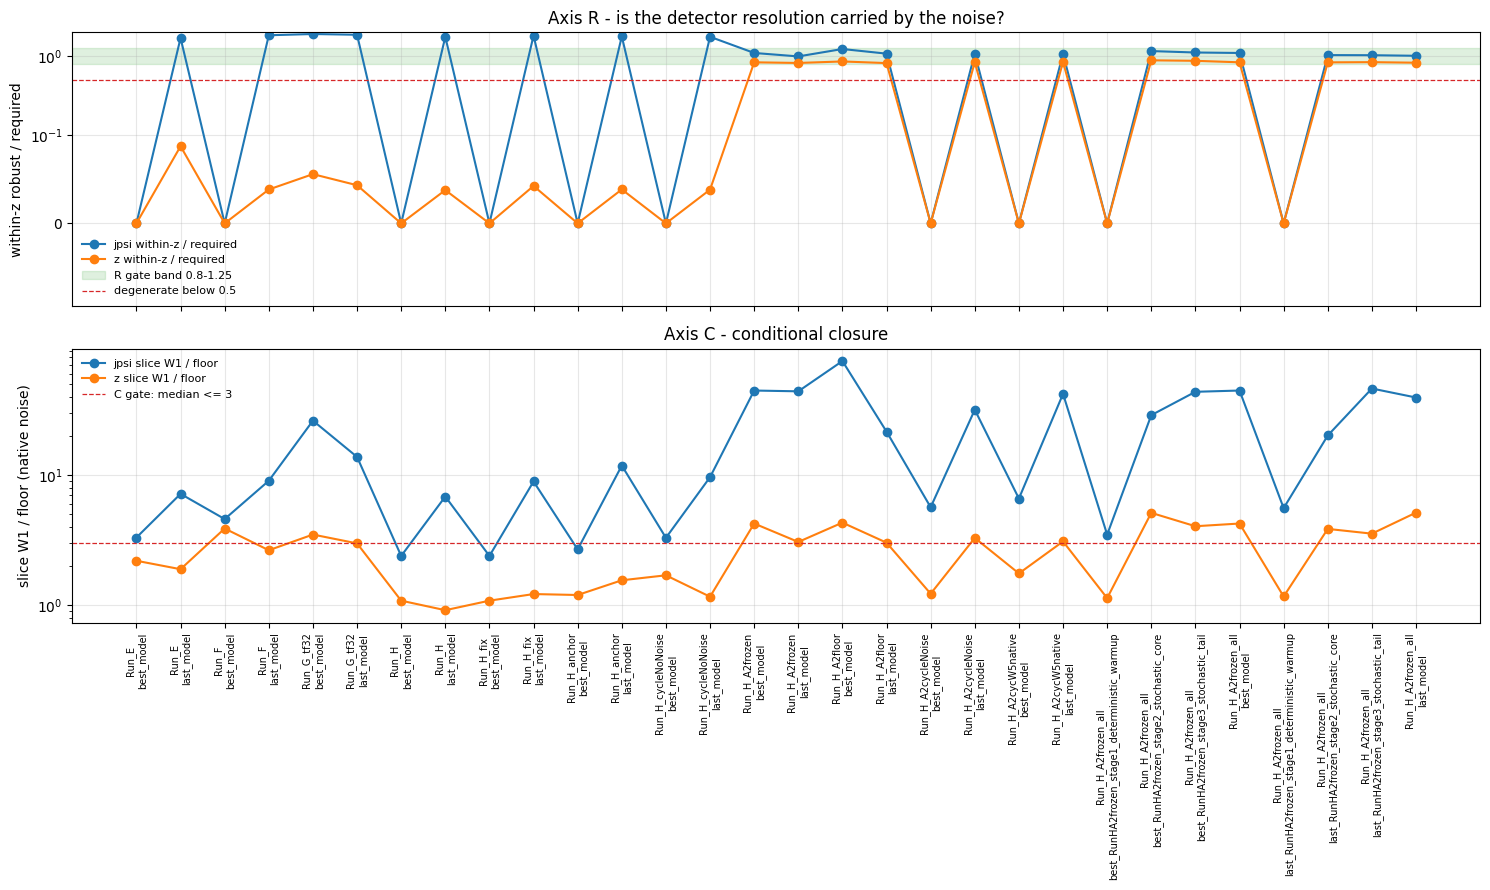

In [6]:
x = np.arange(len(frame))
labels = [row["run"] + "\n" + row["checkpoint"] for row in frame]
jpsi_ratio = np.array([np.nan if row["jpsi_ratio"] is None else row["jpsi_ratio"] for row in frame], dtype=float)
z_ratio = np.array([np.nan if row["z_ratio"] is None else row["z_ratio"] for row in frame], dtype=float)
jpsi_slice = np.array([np.nan if row["jpsi_slice"] is None else row["jpsi_slice"] for row in frame], dtype=float)
z_slice = np.array([np.nan if row["z_slice"] is None else row["z_slice"] for row in frame], dtype=float)

figure, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(x, jpsi_ratio, "o-", color="tab:blue", label="jpsi within-z / required")
axes[0].plot(x, z_ratio, "o-", color="tab:orange", label="z within-z / required")
axes[1].plot(x, jpsi_slice, "o-", color="tab:blue", label="jpsi slice W1 / floor")
axes[1].plot(x, z_slice, "o-", color="tab:orange", label="z slice W1 / floor")
axes[0].axhspan(0.8, 1.25, color="tab:green", alpha=0.15, label="R gate band 0.8-1.25")
axes[0].axhline(0.5, color="tab:red", ls="--", lw=0.9, label="degenerate below 0.5")
axes[0].set_yscale("symlog", linthresh=0.1)
axes[0].set_ylabel("within-z robust / required")
axes[0].set_title("Axis R - is the detector resolution carried by the noise?")
axes[1].axhline(3.0, color="tab:red", ls="--", lw=0.9, label="C gate: median <= 3")
axes[1].set_yscale("log")
axes[1].set_ylabel("slice W1 / floor (native noise)")
axes[1].set_title("Axis C - conditional closure")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
for axis in axes:
    axis.legend(frameon=False, fontsize=8)
    axis.grid(alpha=0.3)
figure.tight_layout()
figure.savefig(SCORECARD / "scorecard_runs_E_H.png", dpi=140, bbox_inches="tight")
figure


## Verdicts

Regenerate after any new training arm. The selection key is the A0.4 answer to the A0.3 result
that native-noise marginal scoring picks the deterministic warmup.


In [7]:
print("Automatic verdicts (per run)")
print("=" * 90)
for name in [item for item in RUNS if item in payloads]:
    block = [row for row in frame if row["run"] == name]
    identified = ", ".join(row["checkpoint"] for row in block if row["identified"]) or "none"
    degenerate = ", ".join(row["checkpoint"] for row in block if row["degenerate"]) or "none"
    print(name + ":")
    print("   key:", block[0]["selection"], "-> selected", block[0]["selected"])
    print("   identified:", identified)
    print("   degenerate:", degenerate)
    print("   axis C:", block[0]["slice_status"])
    print("   jpsi within/required:", ", ".join(render(row["jpsi_ratio"], 3) for row in block))
    print("   z within/required:", ", ".join(render(row["z_ratio"], 3) for row in block))
    print("   jpsi slice ratio:", ", ".join(render(row["jpsi_slice"], 2) for row in block))


Automatic verdicts (per run)
Run_E:
   key: identification_failed -> selected last_model
   identified: none
   degenerate: best_model, last_model
   axis C: measured
   jpsi within/required: 0, 1.68
   z within/required: 0, 0.0875
   jpsi slice ratio: 3.3, 7.2
Run_F:
   key: identification_failed -> selected last_model
   identified: none
   degenerate: best_model, last_model
   axis C: measured
   jpsi within/required: 0, 1.82
   z within/required: 0, 0.0384
   jpsi slice ratio: 4.6, 9.1
Run_G_tf32:
   key: identification_failed -> selected best_model
   identified: none
   degenerate: best_model, last_model
   axis C: measured
   jpsi within/required: 1.88, 1.84
   z within/required: 0.0558, 0.0433
   jpsi slice ratio: 26, 14
Run_H:
   key: identification_failed -> selected last_model
   identified: none
   degenerate: best_model, last_model
   axis C: measured
   jpsi within/required: 0, 1.73
   z within/required: 0, 0.0377
   jpsi slice ratio: 2.4, 6.8
Run_H_fix:
   key: identific